## 2. MACHINE LEARNING FOR REGRESSION

In [1]:
# IMPORTS AND DATA LOADING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# SETTINGS
%matplotlib inline

DF_LOCAL_PATH = '/home/niltonpegass/Documents/repositorio_local/zoomcamp_ML/01_intro/car_price.csv'

df = pd.read_csv(DF_LOCAL_PATH)

### 2.2 DATA PREPARATION

In [2]:
# df_split = df['Market Category'].str.split(',', expand=True)
# df_split.columns = [f'MARKET_CAT_[{i+1}]' for i in range(df_split.shape[1])]

# df = pd.concat([df, df_split], axis=1)
# df = df.drop(columns='Market Category')

df.columns = df.columns.str.upper().str.replace(' ', '_')
string_list = list(df.dtypes[df.dtypes == 'str'].index)

for col in string_list:
    df[col] = df[col].str.lower().str.replace(' ', '_').replace('-', '_')

df.head()

,MAKE,MODEL,YEAR,ENGINE_FUEL_TYPE,ENGINE_HP,ENGINE_CYLINDERS,TRANSMISSION_TYPE,DRIVEN_WHEELS,NUMBER_OF_DOORS,MARKET_CATEGORY,VEHICLE_SIZE,VEHICLE_STYLE,HIGHWAY_MPG,CITY_MPG,POPULARITY,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


### 2.3 EXPLORATORY DATA ANALYSIS (EDA)

In [3]:
column_list = ['MAKE', 'MODEL', 'YEAR', 'MSRP']

for col in column_list:
    display(col)
    display(df[col].unique()[:5])
    display(df[col].nunique())
    print('---')

'MAKE'

array(['BMW', 'Audi', 'FIAT', 'Mercedes-Benz', 'Chrysler'], dtype=object)

48

---


'MODEL'

...

---


'MSRP'

array([46135, 40650, 36350, 29450, 34500])

6049

---


In [4]:
display(df.isnull().sum())

MAKE                    0
MODEL                   0
YEAR                    0
ENGINE_FUEL_TYPE        3
ENGINE_HP              69
ENGINE_CYLINDERS       30
TRANSMISSION_TYPE       0
DRIVEN_WHEELS           0
NUMBER_OF_DOORS         6
MARKET_CATEGORY      3742
VEHICLE_SIZE            0
VEHICLE_STYLE           0
HIGHWAY_MPG             0
CITY_MPG                0
POPULARITY              0
MSRP                    0
dtype: int64

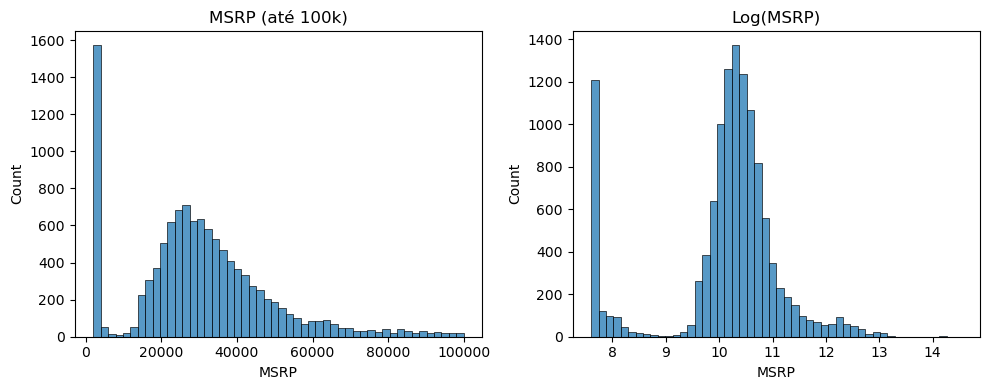

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df.MSRP[df.MSRP <= 0.1e6],
             bins=50,
             ax=axes[0])

# THE LOG TRANSFORMATION CAN HELP TO MAKE THE DISTRIBUTION MORE NORMAL
# WHICH CAN BE BENEFICIAL FOR SOME MACHINE LEARNING MODELS
price_logs = np.log1p(df.MSRP)
sns.histplot(price_logs,
             bins=50,
             ax=axes[1])

axes[0].set_title("MSRP (até 100k)")
axes[1].set_title("Log(MSRP)")

plt.tight_layout()
plt.show()

### 2.4 SETTING UP THE VALIDATION FRAMEWORK

In [6]:
# SETTING UP THE DATA SPLIT
n_train = int(len(df) * 0.6)
n_val = int(len(df) * 0.2)
n_test = len(df) - n_train - n_val

len(df), n_train + n_val + n_test

print(f'n_train: {n_train}\nn_val: {n_val}\nn_test: {n_test}')

n_train: 7148
n_val: 2382
n_test: 2384


In [7]:
# CREATE AN ARRAY OF INDICES AND SHUFFLE IT
# FIX RANDOM SEED FOR REPRODUCIBILITY
idx = np.arange(len(df))

np.random.seed(2)
np.random.shuffle(idx)

# SPLIT DATA INTO TRAIN, VALIDATION AND TEST
# RESET INDEX TO AVOID DUPLICATE INDICES IN THE DATAFRAMES
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train+n_val:]].reset_index(drop=True)

# TARGET VARIABLE LOG TRANSFORMATION
# LOG TRANSFORMATION HELPS TO REDUCE THE EFFECT OF OUTLIERS AND MAKE THE DISTRIBUTION MORE NORMAL
y_train = np.log1p(df_train['MSRP'].values)
y_val = np.log1p(df_val['MSRP'].values)
y_test = np.log1p(df_test['MSRP'].values)

# DROP TARGET VARIABLE FROM DATAFRAMES
# WE WILL USE THE DATAFRAMES TO TRAIN THE MODEL, SO WE NEED TO DROP THE TARGET VARIABLE
del df_train['MSRP']
del df_val['MSRP']
del df_test['MSRP']

In [8]:
# ALTERNATIVE WAY TO SPLIT THE DATA USING SKLEARN

# TRAIN + TEST
df_full_train, df_test = train_test_split(df,
                                          test_size=0.2,
                                          random_state=42)
# TRAIN + VALIDATION
# test_size=0.25 BECAUSE 0.25 * 0.8 = 0.2 (20% OF THE ORIGINAL DATASET)
df_train, df_val = train_test_split(df_full_train,
                                    test_size=0.25,
                                    random_state=42)

print(f'len(df): {len(df)}\nlen(df_train) + len(df_val) + len(df_test): {len(df_train) + len(df_val) + len(df_test)}\n')
print(f'len(df_train): {len(df_train)}\nlen(df_val): {len(df_val)}\nlen(df_test): {len(df_test)}')

# TARGET VARIABLE LOG TRANSFORMATION
# LOG TRANSFORMATION HELPS TO REDUCE THE EFFECT OF OUTLIERS AND MAKE THE DISTRIBUTION MORE NORMAL
y_train = np.log1p(df_train['MSRP'].values)
y_val = np.log1p(df_val['MSRP'].values)
y_test = np.log1p(df_test['MSRP'].values)

# DROP TARGET VARIABLE FROM DATAFRAMES
# WE WILL USE THE DATAFRAMES TO TRAIN THE MODEL, SO WE NEED TO DROP THE TARGET VARIABLE
X_train = df_train.drop(columns='MSRP', inplace=True)
X_val = df_val.drop(columns='MSRP', inplace=True)
X_test = df_test.drop(columns='MSRP', inplace=True)

len(df): 11914
len(df_train) + len(df_val) + len(df_test): 11914

len(df_train): 7148
len(df_val): 2383
len(df_test): 2383


In [9]:
y_train[:5], y_val[:5], y_test[:5]

(array([10.42228135, 10.17526888, 12.42118806, 10.12627104,  9.92700875]),
 array([10.26381581, 11.00544424,  9.90802723, 10.5769676 ,  7.60140233]),
 array([10.29876764, 10.32535081, 10.53611479,  9.69097479,  7.60140233]))

### 2.5 LINEAR REGRESSION

In [10]:
def train_linear_regression(X, y):
    '''
    THIS FUNCTION TRAINS A LINEAR REGRESSION MODEL USING THE NORMAL EQUATION
    IT RETURNS THE COEFFICIENTS OF THE MODEL

    IT WILL RECEIVE THE FEATURE MATRIX X AND THE TARGET VECTOR y AS INPUTS
    AND IT WILL RETURN THE WEIGHTS w AS OUTPUT BY THE FOLLOWING STEPS:

    1. ADD AN INTERCEPT TERM TO THE FEATURE MATRIX X (IT IS NECESSARY BECAUSE THE
    NORMAL EQUATION ASSUMES THAT THE FIRST COLUMN OF X IS THE INTERCEPT TERM)
    2. CALCULATE THE WEIGHTS w USING A MATHEMATICAL FORMULA KNOWN AS THE NORMAL EQUATION
    3. RETURN THE WEIGHTS w

    THE LINEAR ALGEBRA FORMULA FOR THE NORMAL EQUATION IS:
    w = (X^T @ X)^(-1) X^T @ y

    WHERE:
    - X^T IS THE TRANSPOSE OF THE FEATURE MATRIX X
    - (X^T @ X)^(-1) IS THE INVERSE OF THE MATRIX X^T @ X
    - X^T @ y IS THE PRODUCT OF THE TRANSPOSE OF X AND THE TARGET VECTOR y

    np.linalg.inv() CALCULATES THE INVERSE OF A MATRIX
    @ IS THE OPERATOR DEFINED IN PYTHON FOR MATRIX MULTIPLICATION
    .T IS A METHOD IN NUMPY THAT RETURNS THE TRANSPOSE OF UM ARRAY
    '''
    ones = np.ones((X.shape[0], 1)) # ADD INTERCEPT TERM
    X = np.hstack([ones, X])  # ADD INTERCEPT TERM
    w = np.linalg.inv(X.T @ X) @ X.T @ y  # NORMAL EQUATION
    
    return w[0], w[1:]
    

### 2.6 CAR PRICE BASELINE MODEL

In [18]:
# IDENTIFY NUMERIC COLUMNS FOR TRAINING THE MODEL
num_cols = list(df_train.dtypes[(df_train.dtypes == 'int64') | (df_train.dtypes == 'float64')].index)
print(f'NUMERIC COLUMNS: {len(num_cols)}\n{num_cols}\n')

# FILL MISSING VALUES WITH 0 AND CONVERT TO NUMPY ARRAY
X_train = df_train[num_cols].fillna(0).values

# TRAIN THE MODEL USING THE TRAINING DATA
w0, w = train_linear_regression(X_train, y_train)
print(f'w0: {w0}\nw: {w}\n')

# INSPECT THE FIRST 5 PREDICTIONS OF THE MODEL AND THE FIRST 5 ACTUAL VALUES
# THIS IS A QUICK WAY TO CHECK IF THE MODEL IS MAKING SENSE
# THE PREDICTIONS SHOULD BE IN THE SAME SCALE AS THE TARGET VARIABLE (LOG(MSRP))
y_pred = w0 + X_train @ w

print(f'PREDICTIONS: {y_pred[:5]}\nACTUAL: {y_train[:5]}')

NUMERIC COLUMNS: 7
['YEAR', 'ENGINE_HP', 'ENGINE_CYLINDERS', 'NUMBER_OF_DOORS', 'HIGHWAY_MPG', 'CITY_MPG', 'POPULARITY']

w0: -179.5375296071626
w: [ 9.36934765e-02  3.68543532e-03  7.65981529e-02 -3.03802040e-02
 -2.51345333e-03  9.80532519e-03 -4.41529266e-05]

PREDICTIONS: [10.12741632 10.08587795 11.79593016 10.33756938  9.58131991]
ACTUAL: [10.42228135 10.17526888 12.42118806 10.12627104  9.92700875]


### 2.7 R2 AND RMSE

In [ ]:
def r2_score(y_true, y_pred):
    '''
    THIS FUNCTION CALCULATES THE R2 SCORE OF A MODEL
    IT RETURNS THE R2 SCORE AS OUTPUT

    THE R2 SCORE IS A METRIC THAT MEASURES THE PROPORTION OF VARIANCE IN THE TARGET VARIABLE
    THAT IS EXPLAINED BY THE FEATURES IN THE MODEL. IT IS CALCULATED USING THE FOLLOWING FORMULA:

    R2 = 1 - (SS_res / SS_tot)

    WHERE:
    - SS_res IS THE SUM OF SQUARED RESIDUALS (THE SUM OF SQUARED DIFFERENCES BETWEEN THE ACTUAL VALUES AND THE PREDICTED VALUES)
    - SS_tot IS THE TOTAL SUM OF SQUARES (THE SUM OF SQUARED DIFFERENCES BETWEEN THE ACTUAL VALUES AND THE MEAN OF THE ACTUAL VALUES)

    A R2 SCORE OF 1 INDICATES A PERFECT FIT, WHILE A R2 SCORE OF 0 INDICATES THAT THE MODEL DOES NOT EXPLAIN ANY VARIANCE IN THE TARGET VARIABLE.
    '''
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    
    r2 = 1 - (ss_res / ss_tot)
    
    return r2

def rmse_score(y_true, y_pred):
    '''
    THIS FUNCTION CALCULATES THE RMSE SCORE OF A MODEL
    IT RETURNS THE RMSE SCORE AS OUTPUT

    THE RMSE (ROOT MEAN SQUARED ERROR) IS A METRIC THAT MEASURES THE AVERAGE MAGNITUDE OF THE ERRORS IN A SET OF PREDICTIONS. IT IS CALCULATED USING THE FOLLOWING FORMULA:

    RMSE = sqrt(mean((y_true - y_pred) ** 2))

    WHERE:
    - y_true ARE THE ACTUAL VALUES
    - y_pred ARE THE PREDICTED VALUES

    - A LOWER RMSE INDICATES A BETTER FIT OF THE MODEL TO THE DATA.
    - IT RANGES FROM 0 TO INFINITY, WITH 0 INDICATING A PERFECT FIT.
    BUT NORMALLY IT USED TO STAY AT THE SAME SCALE AS THE TARGET VARIABLE, SO IT CAN BE INTERPRETED AS THE AVERAGE ERROR IN THE SAME UNITS AS THE TARGET VARIABLE.
    '''
    se = (y_true - y_pred) ** 2
    mse = np.mean(se)
    rmse = np.sqrt(mse)
    
    return rmse

### 2.8 VALIDATION THE MODEL

In [21]:
def prepare_X(df):
    '''
    THIS FUNCTION PREPARES THE FEATURE MATRIX X FOR PREDICTION
    IT RETURNS THE FEATURE MATRIX X AS OUTPUT

    THE FUNCTION PERFORMS THE FOLLOWING STEPS:
    1. IDENTIFY NUMERIC COLUMNS IN THE DATAFRAME
    2. FILL MISSING VALUES WITH 0
    3. CONVERT THE DATAFRAME TO A NUMPY ARRAY

    THIS FUNCTION IS USEFUL BECAUSE THE MODEL WE TRAINED EXPECTS A NUMPY ARRAY AS INPUT, AND WE NEED TO PREPARE THE DATA IN THE SAME WAY AS WE DID FOR THE TRAINING DATA.
    '''
    num_cols = list(df.dtypes[(df.dtypes == 'int64') | (df.dtypes == 'float64')].index)
    X = df[num_cols].fillna(0).values
    
    return X

In [23]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_val_pred = w0 + X_val @ w

print(f'R2 SCORE: {r2_score(y_val, y_val_pred):.4f}\nRMSE SCORE: {rmse_score(y_val, y_val_pred):.4f}')

R2 SCORE: 0.7882
RMSE SCORE: 0.5196
